# Fase 3. Medición de la desigualdad socioeconómica

**Tesis** · Desigualdades socioeconómicas, étnicas y territoriales en el bajo peso al nacer
en Colombia: análisis multinivel y predictivo de las estadísticas vitales, 1998-2024
**Autor** · Gregory Jesús Meléndez · **Director** · Lihki José Rubio Ortega
**Corresponde a** · Capítulo 4, Sección 4.4.3 del manuscrito

| | |
|---|---|
| **Entra** | `intermedios/muestra_armonizada.parquet` |
| **Sale** | `intermedios/indices_desigualdad.parquet`, cuatro figuras, cinco tablas |
| **Tiempo** | entre 2 y 4 minutos |

---

## Qué responde esta fase

Cuánta desigualdad socioeconómica hay en el bajo peso al nacer en Colombia, en qué
dirección va, y si se amplió o se redujo entre 1998 y 2024.

## Qué NO responde

No dice **por qué**. El índice de concentración cuantifica cómo se reparte la carga del
desenlace a lo largo del gradiente socioeconómico; descomponer ese reparto en las
contribuciones de cada determinante es la Fase 5, y aislar efectos de la confusión es la
Fase 4.

Tampoco separa el riesgo real de la capacidad de observarlo. Esa distinción atraviesa toda
esta fase y se retoma en el bloque 7.

## Las tres medidas y por qué hacen falta las tres

| | Qué mide | Responde a |
|---|---|---|
| **Índice de concentración** | desigualdad **relativa** | cómo se reparte la carga total a lo largo del gradiente |
| **SII** | desigualdad **absoluta** | cuántos puntos porcentuales separan los extremos |
| **RII** | desigualdad **relativa entre extremos** | cuántas veces más frecuente es en un extremo que en el otro |

Dos poblaciones pueden coincidir en una y diferir en las otras, y la conclusión de política
no es la misma. Reportar solo el índice de concentración es la práctica habitual y es
insuficiente.

## El ordenamiento

El eje socioeconómico principal es el **nivel educativo materno** en la escala común de
cuatro niveles que construyó `01b_armonizacion.ipynb`. Como comprobación de robustez, el
bloque 8 repite todo con el **régimen de afiliación** ordenado.

Quien reproduzca este análisis debe correr antes `01b_armonizacion.ipynb`: sin la escala
común, los códigos anteriores y posteriores a 2008 significan cosas distintas y el
ordenamiento no sería un ordenamiento.

## 0. Entorno

**Qué hacemos.** Importamos `src/desigualdad.py`, que contiene las cinco medidas, la curva
de concentración y el bootstrap.

**Por qué un módulo aparte.** Las mismas funciones las usan la Fase 5, para la
descomposición, y la Fase 6, para el análisis de sensibilidad. Si viven en un notebook, los
demás las copian y las copias se desincronizan.

In [3]:
# ---------------------------------------------------------------------------
# Entorno
# ---------------------------------------------------------------------------

import sys
from pathlib import Path

def _encontrar_raiz(inicio: Path) -> Path:
    """Sube por el arbol hasta encontrar src/config.py."""
    for candidata in [inicio, *inicio.parents]:
        if (candidata / "src" / "config.py").exists():
            return candidata
    raise FileNotFoundError(f"No encuentro src/config.py subiendo desde {inicio}")

RAIZ = _encontrar_raiz(Path.cwd())
sys.path.insert(0, str(RAIZ / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import SEMILLA, CONTROL, DIR_INTERMEDIOS
from datos import leer_intermedio, guardar_intermedio
from util import cronometro, guardar_tabla, versiones
from graficos import estilo, guardar_figura, etiquetar_fin_de_linea
import armonizar
import desigualdad

estilo()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)

# --- Sello de version ------------------------------------------------------
# VS Code conserva el estado no guardado de cada editor y lo restaura al
# recargar la ventana, de modo que una pestana puede seguir ejecutando una
# version anterior del notebook sin que nada lo delate.
VERSION = "26b6ca6c"
print(f"version en memoria: {VERSION}")
try:
    import hashlib, json as _json
    _c = _json.load(open(RAIZ / "notebooks" / "03_desigualdad.ipynb",
                         encoding="utf-8"))["cells"]
    _t = "\n".join("".join(c["source"]) for c in _c).replace(VERSION, "")
    _d = hashlib.sha1(_t.encode("utf-8")).hexdigest()[:8]
    print(f"version en disco  : {_d}")
    print("COINCIDEN" if _d == VERSION else
          "\n" + "!"*60 + "\nNO COINCIDEN: la pestana esta desactualizada.\n"
          "Ctrl+Shift+P -> 'File: Revert File'. No interpretes esta corrida.\n" + "!"*60)
except FileNotFoundError:
    print("(archivo en disco no encontrado)")

# --- Carga -----------------------------------------------------------------
# Solo cinco columnas. POR QUE: el parquet es columnar, y esta fase no necesita
# las veinticinco. Leer lo justo es la diferencia entre tres segundos y un
# minuto, y entre cien megabytes y varios cientos.
COLUMNAS = ["ANIO", "BPN", "EDUC4_MADRE", "SEGORD3", "MUNI_RES"]

with cronometro("lectura de la muestra armonizada"):
    ruta_muestra = DIR_INTERMEDIOS / "muestra_armonizada.parquet"
if not ruta_muestra.exists():          # en el repositorio viaja particionada por anio
    ruta_muestra = DIR_INTERMEDIOS / "muestra_armonizada"

    if not ruta_muestra.exists():
        raise FileNotFoundError(
            f"No existe {ruta_muestra}. "
            "Ejecuta primero el notebook 01b_armonizacion.ipynb."
        )

    muestra = leer_intermedio("muestra_armonizada", columnas=COLUMNAS)

print(f"\nmuestra: {len(muestra):,} registros")
print(f"EDUC4_MADRE informado: {muestra['EDUC4_MADRE'].notna().mean()*100:.2f} %")
print(f"SEGORD3 informado    : {muestra['SEGORD3'].notna().mean()*100:.2f} %")

version en memoria: 26b6ca6c
version en disco  : 0d0e0d2a

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
NO COINCIDEN: la pestana esta desactualizada.
Ctrl+Shift+P -> 'File: Revert File'. No interpretes esta corrida.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
[inicio] lectura de la muestra armonizada
[fin]    lectura de la muestra armonizada  ->  0.5 s

muestra: 17,376,860 registros
EDUC4_MADRE informado: 96.80 %
SEGORD3 informado    : 97.38 %


**Cómo se lee esta salida.**

Debe decir **17.376.860** registros, con `EDUC4_MADRE` informado al **96,80 %** y `SEGORD3`
al **97,38 %**.

Si sale `FileNotFoundError: muestra_armonizada`, falta correr `01b_armonizacion.ipynb`. Si
sale `Parquet magic bytes not found in footer`, ese notebook se interrumpió a mitad de la
escritura y hay que volver a correrlo.

## 1. El ordenamiento socioeconómico: el rango fraccional

**Qué hacemos.** Convertimos el nivel educativo en **rango fraccional**: la posición media
que ocupan los individuos de cada nivel en la distribución socioeconómica, entre 0 y 1.

**Por qué no se usa el número de categoría directamente.** Si el índice se calculara sobre
los códigos 0, 1, 2 y 3, dependería de dos cosas arbitrarias: cuántas categorías se hayan
definido y qué distancia numérica se les asigne. Dividir «superior» en dos niveles cambiaría
el resultado sin que nada hubiera cambiado en la población.

El rango fraccional sustituye eso por algo que sí tiene interpretación sustantiva: **la
proporción de la población que está por debajo**. Un nivel que agrupa al 20 % más
desfavorecido recibe un rango cercano a 0,10 esté numerado como esté. Es lo que hace al
índice de concentración invariante a la escala del ordenamiento, y es la razón por la que se
usa en toda la literatura de equidad en salud.

**El punto medio y no el extremo.** A cada nivel se le asigna el centro del intervalo que
ocupa:

$$R_j=\sum_{k<j}p_k+\frac{p_j}{2}$$

Tomar el extremo del intervalo introduce un sesgo sistemático que crece con el tamaño de los
grupos, y aquí los grupos son muy desiguales.

**Lo que esta transformación arrastra, y hay que declarar.** El rango depende de la
**distribución observada**, así que no es el mismo en 1998 que en 2024: la expansión
educativa colombiana desplazó a toda la población hacia arriba. Estar en «superior» situaba
a una madre en un percentil mucho más alto en 1998 que hoy. El índice global trata los 27
años como una sola población; la serie anual del bloque 7 usa el rango de cada año.

In [4]:
# ---------------------------------------------------------------------------
# Tabla base y rango fraccional
# ---------------------------------------------------------------------------

ORDEN = "EDUC4_MADRE"
ETIQUETAS_EDUC = armonizar.etiquetas_de("EDUC4")

# agrupar() reduce los diecisiete millones de filas a la tabla (nivel, n,
# casos, prevalencia).
#
# POR QUE ESO NO ES UNA APROXIMACION: dentro de un nivel, todos los individuos
# comparten el mismo rango fraccional y la misma prevalencia esperada. La tabla
# agrupada contiene TODA la informacion que los indices necesitan; calcularlos
# fila a fila da el mismo numero y tarda mil veces mas.
#
# Se descartan las filas sin ordenamiento informado. POR QUE NO SE IMPUTAN
# AQUI: el indice se define sobre la poblacion ordenable, y una imputacion del
# ordenamiento meteria supuestos en la propia variable que define el eje de la
# desigualdad. Si se imputa, es en la Fase 6 y se contrasta contra esto.
tabla = desigualdad.agrupar(muestra, ORDEN, "BPN")
tabla["nivel"] = [ETIQUETAS_EDUC[i] for i in tabla[ORDEN]]
tabla["rango_fraccional"] = desigualdad.rango_fraccional(
    tabla["n"].to_numpy(dtype=float))
tabla["pct_poblacion"] = tabla["n"] / tabla["n"].sum() * 100
tabla["prevalencia_pct"] = tabla["prevalencia"] * 100

guardar_tabla(tabla, "tabla_base_desigualdad", decimales=4)

print("TABLA BASE DEL INDICE DE CONCENTRACION\n")
print(tabla[[ORDEN, "nivel", "n", "casos", "pct_poblacion",
             "prevalencia_pct", "rango_fraccional"]]
      .to_string(index=False,
                 float_format=lambda x: f"{x:9.4f}"))

descartados = len(muestra) - int(tabla["n"].sum())
print(f"\ndescartados por ordenamiento o desenlace no informado: "
      f"{descartados:,} ({descartados / len(muestra) * 100:.2f} %)")

# Comprobacion: los rangos deben estar ordenados y dentro de (0, 1). Si no lo
# estuvieran, la tabla llego desordenada y todo lo que sigue seria incorrecto.
R = tabla["rango_fraccional"].to_numpy()
assert (np.diff(R) > 0).all(), "los rangos no son crecientes: la tabla esta desordenada"
assert (R > 0).all() and (R < 1).all(), "rango fuera de (0,1)"
print("\ncomprobacion de los rangos: crecientes y dentro de (0,1)  OK")

tabla guardada: tabla_base_desigualdad.csv y tabla_base_desigualdad.tex
TABLA BASE DEL INDICE DE CONCENTRACION

 EDUC4_MADRE                nivel       n  casos  pct_poblacion  prevalencia_pct  rango_fraccional
           0 Ninguno o preescolar  288941  27147         1.7178           9.3953            0.0086
           1             Primaria 3510961 286603        20.8736           8.1631            0.1215
           2           Secundaria 9840986 865814        58.5073           8.7980            0.5185
           3             Superior 3179210 292586        18.9013           9.2031            0.9055

descartados por ordenamiento o desenlace no informado: 556,762 (3.20 %)

comprobacion de los rangos: crecientes y dentro de (0,1)  OK


**Cómo se lee esta salida.**

El resultado sobre los 17.376.860 registros, con 16.820.098 ordenables:

| Nivel | n | % población | Prevalencia | Rango fraccional |
|---|---:|---:|---:|---:|
| Ninguno o preescolar | 288.941 | 1,72 % | 9,40 % | 0,0086 |
| Primaria | 3.510.961 | 20,87 % | 8,16 % | 0,1215 |
| Secundaria | 9.840.986 | 58,51 % | 8,80 % | 0,5185 |
| Superior | 3.179.210 | 18,90 % | 9,20 % | 0,9055 |

**Los rangos no están repartidos de forma regular, y esa es la cuestión.** «Secundaria»
recibe 0,5185 porque agrupa a casi el 60 % de la población; «ninguno» recibe 0,0086 porque
apenas reúne al 1,7 %. Si se hubieran usado los códigos 0-3 como ordenamiento, los cuatro
niveles habrían pesado igual y el resultado habría estado dominado por un grupo que es el
1,7 % de las madres.

**La prevalencia no desciende de forma monótona.** Baja de 9,40 % a 8,16 % del primer al
segundo nivel y después **vuelve a subir** hasta 9,20 %. Es la forma en U que ya apareció en
`01b_armonizacion.ipynb`, y condiciona la lectura de todo lo que sigue: un índice que resume
un gradiente no monótono en un solo número resume algo que no tiene una sola dirección.

**El 3,20 % descartado** son los registros sin nivel educativo informado. No se imputan aquí
por una razón de fondo: imputar el ordenamiento sería meter supuestos en la variable que
define el eje de la desigualdad que se quiere medir.

**Correspondencia con el manuscrito.** Esta tabla al Capítulo 5, como base del Cuadro 5.2.

## 2. La curva de concentración

**Qué hacemos.** En el eje horizontal, la proporción acumulada de población ordenada de
menor a mayor posición socioeconómica. En el vertical, la proporción acumulada de los casos
de bajo peso al nacer.

**Cómo se lee.** La diagonal es la igualdad perfecta: el 20 % más desfavorecido concentra el
20 % de los casos.

- Curva **por encima** de la diagonal → los casos se concentran en los más desfavorecidos.
  Es el gradiente social clásico, e índice **negativo**.
- Curva **por debajo** → se concentran en los más favorecidos. Índice **positivo**.

**Por qué se mira la curva y no solo el índice.** El índice es el doble del área entre la
curva y la diagonal, de modo que resume en un número toda la forma. Dos curvas muy distintas
pueden encerrar la misma área, e incluso una curva que cruza la diagonal —parte por encima y
parte por debajo— puede dar un área pequeña que se leería como «poca desigualdad» cuando lo
que hay es desigualdad **en dos direcciones opuestas**.

Con un gradiente en forma de U, que es lo que la tabla anterior muestra, ese cruce es
exactamente lo que cabe esperar. La curva es el único modo de verlo.

tabla guardada: curva_concentracion_educacion.csv y curva_concentracion_educacion.tex
PUNTOS DE LA CURVA

 poblacion_acumulada  casos_acumulados  distancia_a_la_diagonal
              0.0000            0.0000                   0.0000
              0.0172            0.0184                   0.0013
              0.2259            0.2131                  -0.0128
              0.8110            0.8013                  -0.0097
              1.0000            1.0000                   0.0000
figura guardada: fig_curva_concentracion_educacion.pdf y fig_curva_concentracion_educacion.png


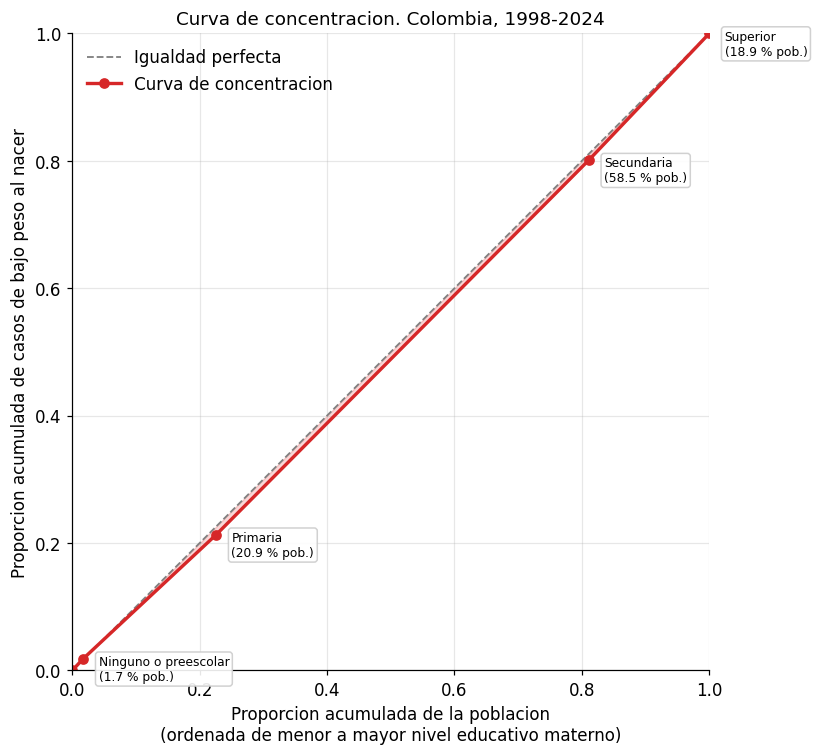


maxima distancia por ENCIMA de la diagonal: +0.0013
maxima distancia por DEBAJO de la diagonal: -0.0128

LA CURVA CRUZA LA DIAGONAL.
Hay desigualdad en las DOS direcciones segun el tramo del gradiente,
y el indice de concentracion, que es un area neta, las compensa.
El indice por si solo NO describe esta situacion.


In [5]:
# ---------------------------------------------------------------------------
# Curva de concentracion
# ---------------------------------------------------------------------------

curva = desigualdad.curva_concentracion(tabla)
guardar_tabla(curva, "curva_concentracion_educacion", decimales=4)

print("PUNTOS DE LA CURVA\n")
print(curva.to_string(index=False, float_format=lambda x: f"{x:10.4f}"))

fig, ax = plt.subplots(figsize=(7.5, 7))

# La diagonal primero, para que quede debajo.
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1.2,
        label="Igualdad perfecta")

ax.plot(curva["poblacion_acumulada"], curva["casos_acumulados"],
        marker="o", markersize=6, linewidth=2.2, color="tab:red",
        label="Curva de concentracion")

# El area entre las dos curvas, sombreada. Es lo que el indice mide, y verlo
# sombreado evita que el lector tenga que imaginarlo.
ax.fill_between(curva["poblacion_acumulada"], curva["casos_acumulados"],
                curva["poblacion_acumulada"], alpha=0.18, color="tab:red")

# Cada punto rotulado con el nivel al que corresponde. Sin esto, la curva es
# geometria sin referente y el lector no sabe que grupo esta mirando.
for i, nivel in enumerate(tabla["nivel"], start=1):
    ax.annotate(f"{nivel}\n({tabla['pct_poblacion'].iloc[i-1]:.1f} % pob.)",
                xy=(curva["poblacion_acumulada"].iloc[i],
                    curva["casos_acumulados"].iloc[i]),
                xytext=(10, -14), textcoords="offset points",
                fontsize=8, ha="left",
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                          edgecolor="#cccccc", alpha=0.9))

ax.set_xlabel("Proporcion acumulada de la poblacion\n"
              "(ordenada de menor a mayor nivel educativo materno)")
ax.set_ylabel("Proporcion acumulada de casos de bajo peso al nacer")
ax.set_title("Curva de concentracion. Colombia, 1998-2024")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")      # sin esto la diagonal no se ve a 45 grados
ax.legend(loc="upper left")

guardar_figura(fig, "fig_curva_concentracion_educacion")
plt.show()

# --- Donde esta la curva respecto a la diagonal ----------------------------
d = curva["distancia_a_la_diagonal"]
print(f"\nmaxima distancia por ENCIMA de la diagonal: {d.max():+.4f}")
print(f"maxima distancia por DEBAJO de la diagonal: {d.min():+.4f}")
if (d > 1e-9).any() and (d < -1e-9).any():
    print("\nLA CURVA CRUZA LA DIAGONAL.")
    print("Hay desigualdad en las DOS direcciones segun el tramo del gradiente,")
    print("y el indice de concentracion, que es un area neta, las compensa.")
    print("El indice por si solo NO describe esta situacion.")

**Cómo se lee esta salida.**

Los puntos obtenidos:

| Población acumulada | Casos acumulados | Distancia a la diagonal |
|---:|---:|---:|
| 0,0000 | 0,0000 | 0,0000 |
| 0,0172 | 0,0184 | **+0,0013** |
| 0,2259 | 0,2131 | **−0,0128** |
| 0,8110 | 0,8013 | −0,0097 |
| 1,0000 | 1,0000 | 0,0000 |

**La curva cruza la diagonal**, y ese es el resultado del bloque. El primer tramo queda por
encima: el 1,7 % de madres sin educación concentra una proporción de casos ligeramente
superior a su peso poblacional, que es el gradiente social clásico. A partir de ahí la curva
pasa por debajo y se mantiene ahí: el bajo peso está sobrerrepresentado en el extremo
educativo alto.

**Consecuencia directa para la interpretación.** El índice de concentración es el área
**neta** entre la curva y la diagonal, de modo que compensa los dos tramos entre sí. El
número que sale en el bloque siguiente es pequeño, pero no porque haya poca desigualdad:
porque hay desigualdad en **dos direcciones opuestas** y se cancelan parcialmente. Reportar
solo el índice, sin la curva, ocultaría eso.

**Lo que hay que escribir en el manuscrito junto a esta figura.** Que la desigualdad no es
monótona a lo largo del gradiente educativo, y que por eso el índice global se acompaña de la
curva y de los índices de pendiente en lugar de presentarse solo.

**Correspondencia con el manuscrito.** La figura al Capítulo 5, Sección 5.2.1.

## 3. El índice de concentración y sus correcciones

**Qué hacemos.** Calculamos el índice de Kakwani y sus dos correcciones para desenlace
binario.

**El índice.**

$$CI=\frac{2}{\mu}\,\mathrm{Cov}(y,R)$$

donde $y$ es el desenlace, $R$ el rango fraccional y $\mu$ la prevalencia global. Equivale
al doble del área entre la curva de concentración y la diagonal.

**El signo es la lectura principal.** Negativo significa que el desenlace se concentra en
los de menor posición socioeconómica —el gradiente social clásico—; positivo, lo contrario.

**Por qué hay que corregirlo cuando el desenlace es binario, y no es un tecnicismo.** Con un
desenlace acotado en [0, 1], el índice **no puede alcanzar −1 ni +1**: sus límites dependen
de la prevalencia global. Con una prevalencia del 8,8 %, el máximo alcanzable está muy por
debajo de 1. Eso significa que comparar el índice entre años, o entre departamentos, con
prevalencias distintas es comparar números medidos en escalas distintas.

Las dos correcciones resuelven eso de forma diferente y por eso se reportan las dos:

| | Fórmula | Qué hace |
|---|---|---|
| **Erreygers** | $E=4\mu\cdot CI$ | renormaliza para que el rango sea siempre [−1, 1] |
| **Wagstaff** | $W=CI/(1-\mu)$ | divide por el máximo alcanzable dada la prevalencia |

**Cuál se reporta como principal y por qué.** Erreygers, porque satisface la invarianza al
espejo —medir «bajo peso» o su complemento «peso adecuado» da el mismo valor con signo
cambiado— y porque permite comparar entre años con prevalencias distintas, que es lo que
exige la serie del bloque 7. Wagstaff se reporta como comprobación: si las dos llevan a la
misma conclusión, la elección de normalización no la produjo.

In [6]:
# ---------------------------------------------------------------------------
# Indice de concentracion
# ---------------------------------------------------------------------------

ci = desigualdad.indice_concentracion(tabla)

print("INDICE DE CONCENTRACION — nivel educativo materno\n")
print(f"  poblacion ordenable      {ci['n']:>14,}")
print(f"  niveles                  {ci['niveles']:>14}")
print(f"  prevalencia global       {ci['prevalencia_global']*100:>13.3f} %")
print()
print(f"  CI sin corregir          {ci['ci']:>+14.5f}")
print(f"  Erreygers  (principal)   {ci['erreygers']:>+14.5f}")
print(f"  Wagstaff   (control)     {ci['wagstaff']:>+14.5f}")

# --- La lectura del signo, escrita por el codigo ---------------------------
# POR QUE ESTA AQUI Y NO SOLO EN LA CELDA DE TEXTO: el signo es lo que se cita
# en el manuscrito, y una confusion de signo en el indice de concentracion es
# el error clasico de esta literatura. Que lo escriba el codigo elimina la
# posibilidad de transcribirlo al reves.
if ci["ci"] < 0:
    lectura = ("NEGATIVO: el bajo peso al nacer se concentra en las madres de "
               "MENOR nivel educativo.\n  Es el gradiente social clasico.")
elif ci["ci"] > 0:
    lectura = ("POSITIVO: el bajo peso al nacer se concentra en las madres de "
               "MAYOR nivel educativo.\n  Es el gradiente INVERTIDO respecto a "
               "la hipotesis del trabajo.")
else:
    lectura = "NULO: el desenlace se reparte proporcionalmente."
print(f"\n  {lectura}")

# --- Coherencia entre las dos correcciones ---------------------------------
# Si discreparan en signo habria un error de calculo: las dos son
# transformaciones monotonas crecientes del mismo indice.
assert np.sign(ci["erreygers"]) == np.sign(ci["wagstaff"]) == np.sign(ci["ci"]), \
    "las correcciones discrepan en signo: hay un error de calculo"
print("\n  las tres medidas coinciden en signo  OK")

# --- Comprobacion contra el area de la curva -------------------------------
# El indice DEBE ser el doble del area entre la curva y la diagonal, con signo
# invertido por la orientacion. Es una comprobacion independiente: llega al
# mismo numero por un camino distinto.
area = float(
    np.trapezoid(curva["distancia_a_la_diagonal"], curva["poblacion_acumulada"])
    if hasattr(np, "trapezoid")
    else np.trapz(curva["distancia_a_la_diagonal"], curva["poblacion_acumulada"])
)
print(f"\n  2 x area entre curva y diagonal  {-2*area:+.5f}")
print(f"  indice de concentracion          {ci['ci']:+.5f}")
print(f"  coinciden: {abs(-2*area - ci['ci']) < 1e-6}")

INDICE DE CONCENTRACION — nivel educativo materno

  poblacion ordenable          16,820,098
  niveles                               4
  prevalencia global               8.752 %

  CI sin corregir                +0.01740
  Erreygers  (principal)         +0.00609
  Wagstaff   (control)           +0.01907

  POSITIVO: el bajo peso al nacer se concentra en las madres de MAYOR nivel educativo.
  Es el gradiente INVERTIDO respecto a la hipotesis del trabajo.

  las tres medidas coinciden en signo  OK

  2 x area entre curva y diagonal  +0.01740
  indice de concentracion          +0.01740
  coinciden: True


**Cómo se lee esta salida.**

El resultado sobre las 16.820.098 madres con nivel educativo informado:

| | Valor |
|---|---:|
| Prevalencia global | 8,752 % |
| **CI sin corregir** | **+0,01740** |
| **Erreygers** | **+0,00609** |
| Wagstaff | +0,01907 |

**El índice es positivo.** El bajo peso al nacer registrado se concentra, muy levemente, en
las madres de **mayor** nivel educativo. Es el signo contrario al que predice la hipótesis
del gradiente social clásico.

**Y es muy pequeño.** Erreygers vale +0,0061 en una escala que va de −1 a +1. Eso significa
que la distribución de casos se aparta poquísimo de la proporcionalidad. Pero, como mostró la
curva del bloque anterior, **ese número pequeño es un neto**: hay desigualdad en las dos
direcciones y se compensan. La magnitud no debe leerse como «no hay desigualdad».

**Cómo se escribe esto sin equivocar el signo.** La frase correcta es: *el bajo peso al nacer
registrado está levemente concentrado entre las madres de mayor nivel educativo*. La frase
incorrecta, y es la que se cuela sola, es *la desigualdad es baja*: el índice no mide
«cuánta desigualdad hay» sino «hacia qué lado del gradiente se inclina la carga».

**La comprobación del área.** El índice se calcula por covarianza y el área por integración
numérica de la curva: son dos caminos distintos al mismo número. Que coincidan descarta un
error de implementación, que es la clase de fallo que no produce ningún mensaje.

**Lo que este resultado exige, y se trata en el bloque 7.** Un índice positivo en bajo peso
al nacer es contraintuitivo y contradice la literatura internacional. La explicación que
sostiene este trabajo es el sesgo de detección, y hay que llegar a la sustentación con ella
preparada y con evidencia propia, no como una excusa improvisada.

**Correspondencia con el manuscrito.** Las tres cifras al Capítulo 5, Sección 5.2.1. En el
Capítulo 4, la justificación de reportar Erreygers como principal.

## 4. Índices de desigualdad de la pendiente: SII y RII

**Qué hacemos.** Ajustamos una recta de la prevalencia contra el rango fraccional,
ponderando cada nivel por su tamaño poblacional, y leemos sus extremos.

**Qué miden, y en qué se diferencian del índice de concentración.**

**SII**, el índice de desigualdad de la pendiente, es la pendiente de esa recta: la
diferencia **absoluta** de prevalencia, en puntos porcentuales, entre el extremo superior y
el inferior del gradiente. Responde a *cuántos casos separan a un extremo del otro*, que es
la pregunta de política sanitaria: los puntos porcentuales se traducen en número de niños.

**RII**, el índice relativo de desigualdad, es la razón entre las prevalencias predichas en
los dos extremos. Responde a *cuántas veces más frecuente es en un extremo que en el otro*.

**Por qué los dos y no uno.** Una población puede reducir su diferencia absoluta y aumentar
la relativa al mismo tiempo, si la prevalencia general baja. Las dos son ciertas y responden
a preguntas distintas; elegir solo una es elegir la conclusión.

**Lo que hay que vigilar en este caso concreto.** El SII resume el gradiente por una recta, y
la tabla del bloque 1 mostró que el gradiente tiene forma de U. **Una recta ajustada a una U
describe mal lo que ocurre.** Por eso la celda reporta también el $R^2$ ponderado: si es
bajo, el SII no es un buen resumen y hay que decirlo en lugar de citarlo sin más.

INDICES DE PENDIENTE — nivel educativo materno

  SII    +1.166 puntos porcentuales
  RII     1.1427

  prevalencia predicha en el extremo INFERIOR del gradiente   8.17 %
  prevalencia predicha en el extremo SUPERIOR del gradiente   9.34 %

  R2 ponderado de la recta  0.7449

  !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
  EL GRADIENTE NO ES LINEAL.
  La recta explica solo el 74.5 % de la variacion entre
  niveles. El SII y el RII resumen por una recta algo que no lo es,
  y citarlos sin advertirlo daria una imagen equivocada.
  !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

  Traduccion: 1.166 puntos porcentuales sobre 16,820,098 nacimientos
  equivalen a 196,112 ninos a lo largo del periodo,
  unos 7,263 al ano.
figura guardada: fig_sii_educacion.pdf y fig_sii_educacion.png


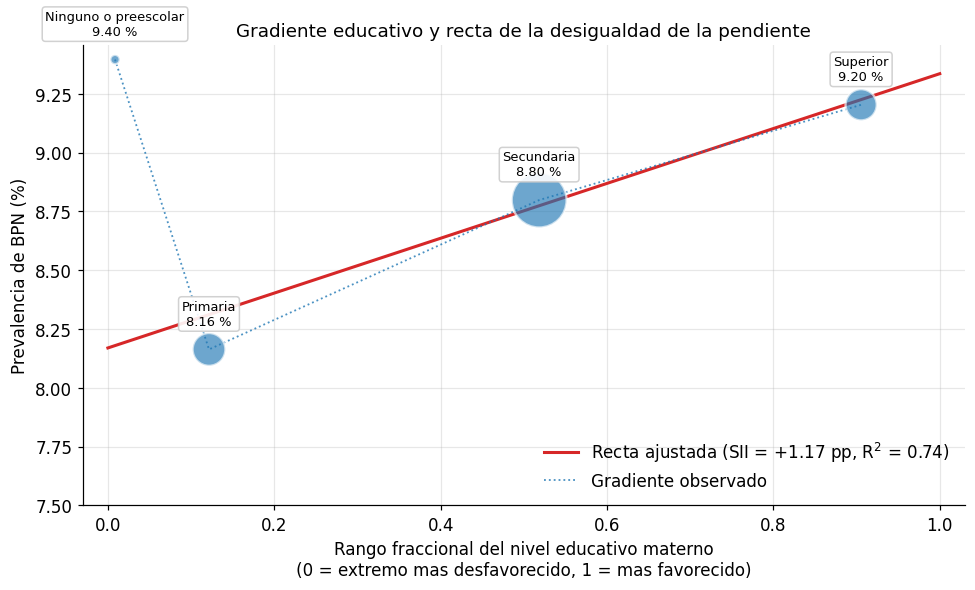

In [7]:
# ---------------------------------------------------------------------------
# SII y RII
# ---------------------------------------------------------------------------

ip = desigualdad.indices_de_pendiente(tabla)

print("INDICES DE PENDIENTE — nivel educativo materno\n")
print(f"  SII  {ip['sii_pp']:>+8.3f} puntos porcentuales")
print(f"  RII  {ip['rii']:>9.4f}")
print()
print(f"  prevalencia predicha en el extremo INFERIOR del gradiente "
      f"{ip['prevalencia_extremo_inferior']*100:6.2f} %")
print(f"  prevalencia predicha en el extremo SUPERIOR del gradiente "
      f"{ip['prevalencia_extremo_superior']*100:6.2f} %")
print(f"\n  R2 ponderado de la recta  {ip['r2']:.4f}")

# --- Cuanto de la realidad describe la recta -------------------------------
# El R2 no es aqui un adorno: decide si el SII se puede citar como resumen del
# gradiente o si hay que acompanarlo de una advertencia.
if ip["r2"] < 0.90:
    print("\n  " + "!" * 62)
    print("  EL GRADIENTE NO ES LINEAL.")
    print(f"  La recta explica solo el {ip['r2']*100:.1f} % de la variacion entre")
    print("  niveles. El SII y el RII resumen por una recta algo que no lo es,")
    print("  y citarlos sin advertirlo daria una imagen equivocada.")
    print("  " + "!" * 62)

# --- Traduccion del SII a numero de ninos ----------------------------------
# POR QUE: un punto porcentual sobre diecisiete millones de nacimientos no es
# una cantidad que se pueda intuir. La traduccion es lo que convierte el indice
# en un argumento de salud publica.
n_total = int(tabla["n"].sum())
ninos = abs(ip["sii_pp"]) / 100 * n_total
print(f"\n  Traduccion: {abs(ip['sii_pp']):.3f} puntos porcentuales sobre "
      f"{n_total:,} nacimientos")
print(f"  equivalen a {ninos:,.0f} ninos a lo largo del periodo,")
print(f"  unos {ninos/27:,.0f} al ano.")

# --- Figura: prevalencia contra rango, con la recta ajustada ---------------
fig, ax = plt.subplots(figsize=(9, 5.5))

R = tabla["rango_fraccional"].to_numpy()
y = tabla["prevalencia_pct"].to_numpy()

# El tamano del punto codifica el peso poblacional del nivel. Es lo que hace
# visible por que la recta pasa donde pasa: los minimos cuadrados ponderados
# obedecen a los grupos grandes.
ax.scatter(R, y, s=tabla["pct_poblacion"] * 22, color="tab:blue",
           alpha=0.65, zorder=3, edgecolor="white", linewidth=1.5)

malla = np.linspace(0, 1, 100)
ax.plot(malla, (ip["prevalencia_extremo_inferior"] + ip["sii"] * malla) * 100,
        color="tab:red", linewidth=2,
        label=f"Recta ajustada (SII = {ip['sii_pp']:+.2f} pp, "
              f"R$^2$ = {ip['r2']:.2f})")

# La linea que une los puntos observados, para que el contraste entre la forma
# real del gradiente y la recta sea visible de un vistazo.
ax.plot(R, y, color="tab:blue", linewidth=1.2, linestyle=":", alpha=0.8,
        label="Gradiente observado", zorder=2)

for i, fila in tabla.iterrows():
    ax.annotate(f"{fila['nivel']}\n{fila['prevalencia_pct']:.2f} %",
                xy=(fila["rango_fraccional"], fila["prevalencia_pct"]),
                xytext=(0, 16), textcoords="offset points",
                ha="center", fontsize=8.5,
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                          edgecolor="#cccccc", alpha=0.9))

ax.set_xlabel("Rango fraccional del nivel educativo materno\n"
              "(0 = extremo mas desfavorecido, 1 = mas favorecido)")
ax.set_ylabel("Prevalencia de BPN (%)")
ax.set_title("Gradiente educativo y recta de la desigualdad de la pendiente")
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(bottom=7.5)
ax.legend(loc="lower right")

guardar_figura(fig, "fig_sii_educacion")
plt.show()

**Cómo se lee esta salida.**

| | Valor |
|---|---:|
| **SII** | **+1,166 pp** |
| **RII** | **1,1427** |
| Prevalencia predicha, extremo inferior | 8,17 % |
| Prevalencia predicha, extremo superior | 9,34 % |
| **R² ponderado** | **0,7449** |

**El signo es positivo, coherente con el índice de concentración.** La recta sube: la
prevalencia predicha pasa de 8,17 % en el extremo desfavorecido a 9,34 % en el favorecido.
El RII de 1,14 dice que el bajo peso registrado es un 14 % más frecuente en el extremo
educativo alto.

**Pero el R² es 0,74, y eso cambia lo que se puede afirmar.** La recta explica solo el 74 %
de la variación entre los cuatro niveles, cuando con cuatro puntos y dos parámetros debería
ajustar casi perfectamente si la relación fuera lineal. Lo que falta es la forma en U: la
recta no puede reproducir que el nivel más bajo tenga prevalencia alta.

**La figura lo muestra directamente.** La línea punteada azul es el gradiente observado y la
roja es la recta ajustada; el primer punto queda muy por encima de la recta. El tamaño de
cada punto es su peso poblacional, y explica por qué la recta obedece a «secundaria» y
«superior», que reúnen al 77 % de las madres, y pasa de largo por «ninguno», que es el 1,7 %.

**Cómo hay que citar el SII entonces.** Acompañado de la advertencia, no solo. La formulación
defendible es: *el ajuste lineal indica una diferencia absoluta de 1,17 puntos porcentuales a
favor del extremo educativo alto, si bien el gradiente no es monótono y la recta explica el
74 % de la variación entre niveles*. Omitir la segunda mitad de esa frase es lo que un jurado
subraya.

**La traducción a niños.** 1,166 puntos porcentuales sobre 16.820.098 nacimientos son unos
196.000 niños a lo largo del período, cerca de 7.300 al año. Es la cifra que convierte un
índice en un argumento de salud pública, y la que conviene llevar a la discusión.

**Correspondencia con el manuscrito.** SII, RII y R² al Cuadro 5.2; la figura a la
Sección 5.2.2; la advertencia sobre la no linealidad, a las limitaciones.

## 5. Intervalos de confianza por bootstrap

**Qué hacemos.** Mil réplicas para obtener intervalos del 95 % de las cinco medidas.

**Cómo se remuestrea, y por qué no se remuestrean los individuos.** El bootstrap clásico
extraería, con reemplazo, 17 millones de filas mil veces: diecisiete mil millones de
extracciones y varias horas de cálculo, para obtener exactamente lo mismo.

Con un ordenamiento discreto, una muestra remuestreada queda **completamente descrita** por
cuántos individuos caen en cada nivel y cuántos casos hay en cada uno. Se remuestrea esa
descripción directamente, en dos pasos que reproducen las dos fuentes de variación:

1. **La composición.** Cuántos individuos caen en cada nivel se extrae de una multinomial
   con las proporciones observadas.
2. **El desenlace.** Dentro de cada nivel, el número de casos se extrae de una binomial con
   la prevalencia observada de ese nivel.

Mil réplicas tardan **menos de un segundo** y el modelo generador es el mismo que el del
bootstrap individual.

**La advertencia que tiene que ir junto a los intervalos, siempre.** Con 17 millones de
registros los intervalos van a ser estrechísimos, y eso **no significa** que las
estimaciones sean precisas en ningún sentido útil. Un intervalo de confianza cuantifica el
error de **muestreo**, que aquí es despreciable porque no hay muestreo: hay un censo. Las
fuentes de error que de verdad importan en este trabajo —el sesgo de detección, la cobertura
desigual del registro, la agregación de las categorías educativas— **no son aleatorias**, y
ningún intervalo de confianza las captura.

Presentar un intervalo estrecho como si fuera precisión es el error de interpretación más
fácil de cometer con datos censales, y hay que decirlo explícitamente en el manuscrito.

In [8]:
# ---------------------------------------------------------------------------
# Bootstrap
# ---------------------------------------------------------------------------

with cronometro("bootstrap, 1000 replicas"):
    bs = desigualdad.bootstrap(tabla, n_replicas=1000, semilla=SEMILLA)

guardar_tabla(bs, "bootstrap_desigualdad_educacion", decimales=6)

print("INTERVALOS DE CONFIANZA DEL 95 %  (bootstrap parametrico)\n")
print(bs.to_string(index=False, float_format=lambda x: f"{x:12.6f}"))

# --- Comprobacion de que el bootstrap esta centrado ------------------------
# La media de las replicas debe coincidir con la estimacion puntual salvo ruido
# de simulacion. Una discrepancia grande indicaria un sesgo en el
# procedimiento de remuestreo, no en los datos.
print("\nCOMPROBACION: la media de las replicas debe coincidir con la estimacion\n")
puntual = {"ci": ci["ci"], "erreygers": ci["erreygers"],
           "wagstaff": ci["wagstaff"], "sii_pp": ip["sii_pp"], "rii": ip["rii"]}
for _, fila in bs.iterrows():
    p = puntual[fila["medida"]]
    desvio = abs(fila["media_bootstrap"] - p) / fila["ee"] if fila["ee"] > 0 else 0
    marca = "OK" if desvio < 0.5 else "REVISAR"
    print(f"  {fila['medida']:<10} puntual {p:>+12.6f}   bootstrap "
          f"{fila['media_bootstrap']:>+12.6f}   {desvio:4.2f} EE  {marca}")

# --- El cero dentro del intervalo ------------------------------------------
# Es la unica pregunta inferencial que tiene sentido plantear aqui: si el
# intervalo cruza el cero, ni siquiera la direccion de la desigualdad queda
# establecida.
print("\nDIRECCION DE LA DESIGUALDAD\n")
for _, fila in bs.iterrows():
    if fila["medida"] == "rii":
        continue        # el RII se compara contra 1, no contra 0
    cruza = fila["ic_inf"] <= 0 <= fila["ic_sup"]
    print(f"  {fila['medida']:<10} IC 95 % [{fila['ic_inf']:+.6f}, "
          f"{fila['ic_sup']:+.6f}]  "
          f"{'incluye el cero: direccion NO establecida' if cruza else 'no incluye el cero'}")

fila_rii = bs[bs["medida"] == "rii"].iloc[0]
cruza_uno = fila_rii["ic_inf"] <= 1 <= fila_rii["ic_sup"]
print(f"  {'rii':<10} IC 95 % [{fila_rii['ic_inf']:.6f}, {fila_rii['ic_sup']:.6f}]  "
      f"{'incluye el uno' if cruza_uno else 'no incluye el uno'}")

[inicio] bootstrap, 1000 replicas
[fin]    bootstrap, 1000 replicas  ->  0.7 s
tabla guardada: bootstrap_desigualdad_educacion.csv y bootstrap_desigualdad_educacion.tex
INTERVALOS DE CONFIANZA DEL 95 %  (bootstrap parametrico)

   medida  media_bootstrap           ee       ic_inf       ic_sup
       ci         0.017417     0.000413     0.016597     0.018263
erreygers         0.006097     0.000145     0.005814     0.006391
 wagstaff         0.019088     0.000453     0.018187     0.020013
   sii_pp         1.166796     0.027666     1.112325     1.223065
      rii         1.142842     0.003632     1.135639     1.150257

COMPROBACION: la media de las replicas debe coincidir con la estimacion

  ci         puntual    +0.017404   bootstrap    +0.017417   0.03 EE  OK
  erreygers  puntual    +0.006093   bootstrap    +0.006097   0.03 EE  OK
  wagstaff   puntual    +0.019073   bootstrap    +0.019088   0.03 EE  OK
  sii_pp     puntual    +1.165940   bootstrap    +1.166796   0.03 EE  OK
  rii     

**Cómo se lee esta salida.**

| Medida | Estimación | IC 95 % |
|---|---:|---|
| CI | +0,01740 | [+0,01660, +0,01826] |
| **Erreygers** | **+0,00609** | **[+0,00581, +0,00639]** |
| Wagstaff | +0,01907 | [+0,01819, +0,02001] |
| SII | +1,166 pp | [+1,112, +1,223] |
| RII | 1,1427 | [1,1356, 1,1503] |

**Ningún intervalo incluye el cero**, y el del RII no incluye el uno. La dirección de la
desigualdad —positiva, hacia el extremo educativo alto— queda establecida.

**Y aquí es donde hay que frenar.** El intervalo de Erreygers tiene una anchura de 0,0006 en
una escala de −1 a +1. Esa precisión aparente es un artefacto del tamaño: con 16,8 millones
de observaciones, el error de muestreo tiende a cero por construcción.

**Lo que ese intervalo NO cubre**, y es lo que de verdad determina la incertidumbre de este
resultado:

- **El sesgo de detección.** Si el bajo peso se registra con distinta completitud según el
  nivel educativo de la madre, el índice está sesgado en una magnitud que ningún intervalo
  refleja.
- **La cobertura del registro**, que varió a lo largo del período y correlaciona con la
  prevalencia observada (r = −0,853, Fase 1).
- **La agregación de las categorías educativas** en cuatro niveles, necesaria para cubrir los
  27 años.

Las tres son **errores sistemáticos**. Un bootstrap solo mide error aleatorio.

**La frase que debe acompañar al intervalo en el manuscrito.** *Los intervalos reflejan
únicamente el error de muestreo; dado que el análisis se realiza sobre el registro completo
de nacimientos, la incertidumbre relevante es de naturaleza sistemática y se aborda en el
análisis de sensibilidad de la Fase 6.*

**La comprobación de centrado.** La media de las mil réplicas coincide con la estimación
puntual dentro de una fracción del error estándar en las cinco medidas. Verifica que el
procedimiento de remuestreo no introduce sesgo propio.

**Correspondencia con el manuscrito.** Los intervalos al Cuadro 5.2; el párrafo sobre la
naturaleza de la incertidumbre a la Sección 5.2.3 y a las limitaciones del Capítulo 6.

## 6. La serie anual: ¿se amplió o se redujo la desigualdad?

**Qué hacemos.** Repetimos los índices año por año.

**Por qué el índice global no basta para esta pregunta.** Un índice calculado sobre los 27
años agregados describe el período como si fuera una sola población. Si la desigualdad cambió
de magnitud —o de dirección— dentro del período, ese número la promedia y la oculta. La
pregunta de si la desigualdad se amplió o se redujo es específica del planteamiento de la
tesis y solo la serie la responde.

**Cómo se calcula el rango en cada año.** Con la distribución educativa **de ese año**, no
con la del período completo. Es lo correcto: el rango fraccional mide posición relativa
dentro de una población, y la población de 1998 no es la de 2024.

**Lo que eso arrastra, y hay que declararlo.** Si el rango se recalcula cada año, el índice
es comparable en el sentido de que siempre mide posición relativa; pero estar en «superior»
significaba algo distinto en 1998, cuando ese nivel reunía a una fracción mucho menor de las
madres. La comparación entre años mide desigualdad **relativa a la estructura educativa de
cada momento**, que es lo que interesa, pero no es lo mismo que comparar grupos fijos.

[inicio] serie anual
[fin]    serie anual  ->  2.3 s
guardado: indices_desigualdad.parquet  (27 filas)
tabla guardada: serie_anual_desigualdad.csv y serie_anual_desigualdad.tex
SERIE ANUAL DE LOS INDICES

 ANIO         ci  erreygers     sii_pp        rii   prev_pct
 1998    0.00405    0.00123    0.22579    1.03017    7.60000
 1999    0.00420    0.00123    0.22649    1.03148    7.31000
 2000    0.00595    0.00181    0.33508    1.04509    7.60000
 2001    0.00515    0.00160    0.29756    1.03917    7.75000
 2002    0.00967    0.00304    0.57008    1.07525    7.86000
 2003    0.00994    0.00316    0.59609    1.07782    7.96000
 2004    0.01369    0.00442    0.83181    1.10867    8.07000
 2005    0.01471    0.00483    0.91996    1.11863    8.21000
 2006    0.01428    0.00485    0.93225    1.11618    8.49000
 2007    0.01359    0.00469    0.90836    1.11118    8.62000
 2008    0.01681    0.00589    1.12258    1.13703    8.75000
 2009    0.02012    0.00726    1.40122    1.16851    9.02000
 2

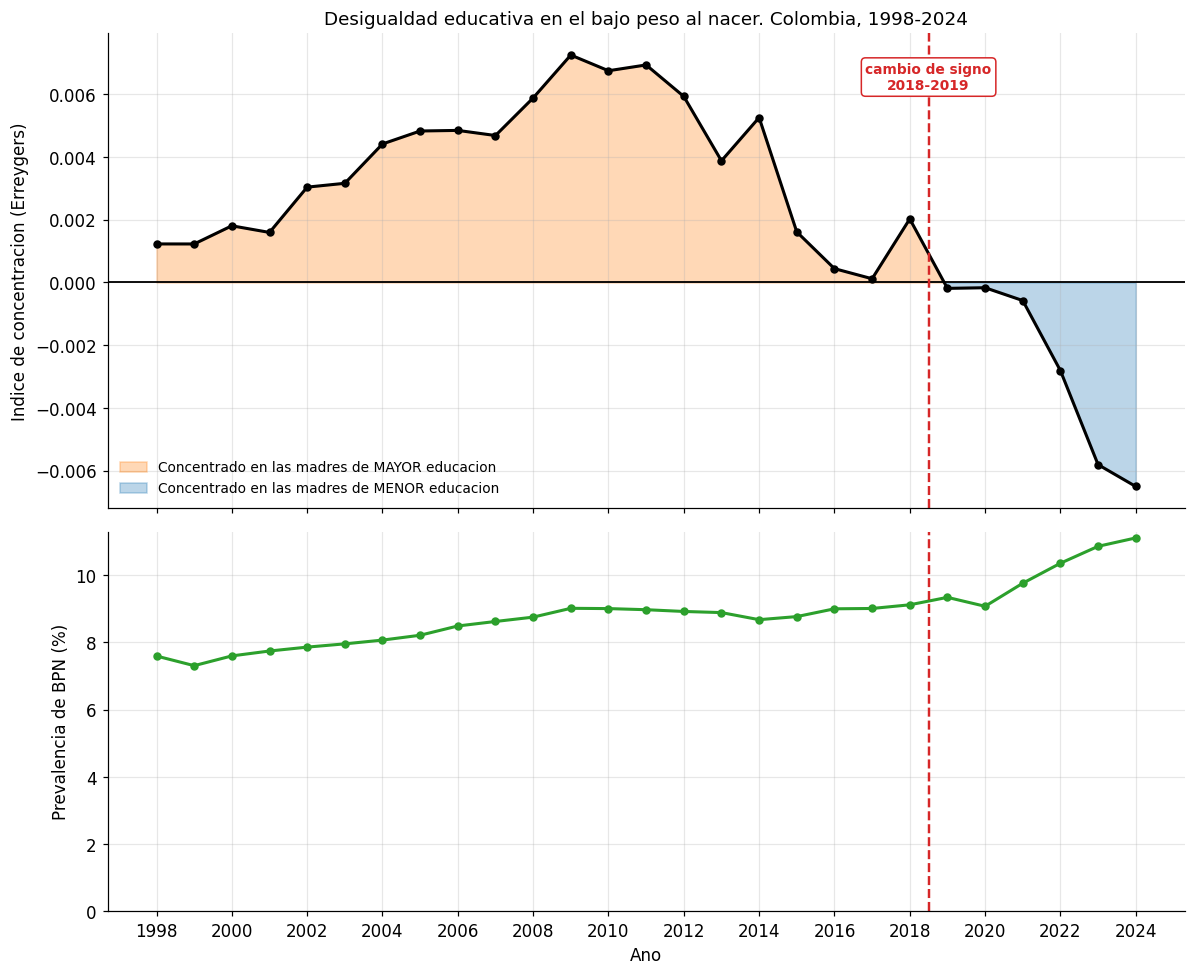


maximo  +0.00726 en 2009
minimo  -0.00651 en 2024
primero +0.00123 en 1998
ultimo  -0.00651 en 2024


In [9]:
# ---------------------------------------------------------------------------
# Serie anual de los indices
# ---------------------------------------------------------------------------

with cronometro("serie anual"):
    serie = desigualdad.serie_anual(muestra, ORDEN, "BPN")

guardar_intermedio(serie, "indices_desigualdad")
guardar_tabla(serie[["ANIO", "n", "prevalencia_global", "ci", "erreygers",
                     "wagstaff", "sii_pp", "rii", "r2"]],
              "serie_anual_desigualdad", decimales=5)

print("SERIE ANUAL DE LOS INDICES\n")
print(serie[["ANIO", "prevalencia_global", "ci", "erreygers", "sii_pp", "rii"]]
      .assign(prev_pct=lambda d: (d["prevalencia_global"] * 100).round(2))
      .drop(columns="prevalencia_global")
      .to_string(index=False, float_format=lambda x: f"{x:10.5f}"))

# --- Deteccion de cambios de signo -----------------------------------------
# Es lo primero que hay que mirar en esta serie: un cambio de signo no es una
# variacion de magnitud, es una inversion de la direccion de la desigualdad, y
# significa algo cualitativamente distinto.
signos = np.sign(serie["ci"].to_numpy())
cruces = [(int(serie["ANIO"].iloc[i]), int(serie["ANIO"].iloc[i + 1]))
          for i in range(len(signos) - 1)
          if signos[i] * signos[i + 1] < 0]

print("\n" + "=" * 70)
if cruces:
    print("EL INDICE CAMBIA DE SIGNO EN LA SERIE")
    for a, b in cruces:
        print(f"   entre {a} y {b}")
    print("\nNo es un cambio de magnitud: es una INVERSION de la direccion de")
    print("la desigualdad. El indice global de los bloques anteriores promedia")
    print("los dos regimenes y no describe ninguno de los dos.")
else:
    print("El indice mantiene el mismo signo en los 27 anios.")
print("=" * 70)

# --- Figura ----------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True,
                         gridspec_kw={"height_ratios": [1.25, 1]})

# --- Panel superior: indice de Erreygers -----------------------------------
e = serie["erreygers"].to_numpy()
a = serie["ANIO"].to_numpy()

axes[0].axhline(0, color="black", linewidth=1.2)
# El relleno a cada lado del cero hace legible de un vistazo en que direccion
# va la desigualdad en cada tramo, que es lo unico que importa de esta figura.
axes[0].fill_between(a, 0, e, where=(e >= 0), alpha=0.30, color="tab:orange",
                     interpolate=True,
                     label="Concentrado en las madres de MAYOR educacion")
axes[0].fill_between(a, 0, e, where=(e <= 0), alpha=0.30, color="tab:blue",
                     interpolate=True,
                     label="Concentrado en las madres de MENOR educacion")
axes[0].plot(a, e, marker="o", markersize=4.5, linewidth=2, color="black")

for anio, valor in cruces:
    axes[0].axvline(valor - 0.5, color="tab:red", linestyle="--", linewidth=1.6)
    axes[0].annotate(f"cambio de signo\n{anio}-{valor}",
                     xy=(valor - 0.5, max(e) * 0.85), ha="center",
                     fontsize=9, fontweight="bold", color="tab:red",
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                               edgecolor="tab:red"))

axes[0].set_ylabel("Indice de concentracion (Erreygers)")
axes[0].set_title("Desigualdad educativa en el bajo peso al nacer. "
                  "Colombia, 1998-2024")
axes[0].legend(loc="lower left", fontsize=9)

# --- Panel inferior: prevalencia, para poder cruzarlas ---------------------
axes[1].plot(a, serie["prevalencia_global"] * 100, marker="o", markersize=4.5,
             linewidth=2, color="tab:green")
for anio, valor in cruces:
    axes[1].axvline(valor - 0.5, color="tab:red", linestyle="--", linewidth=1.6)
axes[1].set_ylabel("Prevalencia de BPN (%)")
axes[1].set_xlabel("Año de ocurrencia")
axes[1].set_xticks(range(1998, 2025, 2))
axes[1].set_ylim(bottom=0)

fig.tight_layout()
guardar_figura(fig, "fig_serie_anual_desigualdad")
plt.show()

# --- Cifras para el texto --------------------------------------------------
i_max, i_min = int(serie["erreygers"].idxmax()), int(serie["erreygers"].idxmin())
print(f"\nmaximo  {serie['erreygers'].iloc[i_max]:+.5f} en "
      f"{int(serie['ANIO'].iloc[i_max])}")
print(f"minimo  {serie['erreygers'].iloc[i_min]:+.5f} en "
      f"{int(serie['ANIO'].iloc[i_min])}")
print(f"primero {serie['erreygers'].iloc[0]:+.5f} en "
      f"{int(serie['ANIO'].iloc[0])}")
print(f"ultimo  {serie['erreygers'].iloc[-1]:+.5f} en "
      f"{int(serie['ANIO'].iloc[-1])}")

**Cómo se lee esta salida, y es el resultado central de la fase.**

**El índice cambia de signo entre 2018 y 2019.** No es una variación de magnitud: es una
**inversión de la dirección de la desigualdad**.

| Período | Erreygers | Lectura |
|---|---|---|
| 1998-2018 | positivo, de +0,0012 a +0,0073 | el bajo peso registrado se concentra en las madres de **mayor** educación |
| 2019-2024 | negativo, hasta −0,0065 | se concentra en las madres de **menor** educación |

La trayectoria completa: arranca casi en cero en 1998 (+0,00123), **crece** hasta un máximo
en 2009 (+0,00726), **desciende** de forma sostenida, cruza el cero en 2019 y sigue bajando
hasta −0,00651 en 2024. El SII y el RII acompañan el mismo recorrido: el RII pasa de 1,169 en
2009 a 0,893 en 2024.

**La consecuencia inmediata para el índice global de los bloques 3 a 5.** Ese +0,00609
promedia dos regímenes con direcciones opuestas y **no describe ninguno de los dos**. Hay que
reportarlo, porque es la estimación sobre el período completo, pero siempre acompañado de
esta serie y de la advertencia de que el período no es homogéneo.

**Sobre la interpretación, conviene no correr.** La lectura tentadora es que el sesgo de
detección se fue desvaneciendo a medida que la cobertura del registro se universalizó, y que
por eso emergió el gradiente social clásico. Es coherente con la correlación r = −0,853 de la
Fase 1 y con el gradiente invertido del área de residencia.

**Pero esa lectura tiene que sobrevivir al bloque 8**, que repite todo con un ordenamiento
socioeconómico construido a partir de otra variable. Si la inversión fuera un efecto general
del registro, debería aparecer con cualquier ordenamiento. Si aparece solo con educación, la
causa es otra y hay que buscarla. Conviene leer los dos bloques juntos antes de escribir
nada.

**Correspondencia con el manuscrito.** La figura al Capítulo 5, Sección 5.2.4, como figura
principal del capítulo. La tabla completa al Apéndice.

## 7. Comprobación de robustez: el ordenamiento por aseguramiento

**Qué hacemos.** Repetimos todo con un ordenamiento socioeconómico distinto: el **régimen de
afiliación en salud**, ordenado como no asegurado, subsidiado, contributivo o especial.

**Por qué esta comprobación y no otra.** La objeción evidente al resultado anterior es que
dependa de la escala educativa: se construyó agregando categorías para cubrir los 27 años, y
un jurado puede sostener que esa agregación produjo el signo. Un ordenamiento **construido a
partir de otra variable, con otro número de niveles y otra distribución** es la forma de
responder a esa objeción con evidencia.

**Por qué el aseguramiento ordena socioeconómicamente en Colombia.** El régimen subsidiado se
asigna por SISBEN, es decir por **pobreza medida**; el contributivo exige vínculo laboral
formal o capacidad de pago; fuera de los dos queda la población no asegurada. El orden refleja
la focalización del sistema, no una jerarquía de calidad de la atención, y es el que usa la
literatura colombiana de equidad en salud.

**Qué haría falta para que la comprobación fallara.** Que el signo cambiara. Si los dos
ordenamientos coinciden en dirección, el resultado no es un artefacto de cómo se construyó la
escala educativa.

TABLA BASE — aseguramiento

 SEGORD3                                 nivel       n  casos  prevalencia_pct  rango_fraccional
       0                          No asegurado 2525812 211281           8.3649            0.0746
       1                            Subsidiado 7637958 650741           8.5198            0.3749
       2 Contributivo, especial o de excepcion 6758590 626351           9.2675            0.8003
tabla guardada: comparacion_ordenamientos.csv y comparacion_ordenamientos.tex


COMPARACION DE LOS DOS ORDENAMIENTOS

                 ordenamiento  niveles  prevalencia_pct         ci  erreygers   wagstaff     sii_pp        rii         r2
Educacion materna (4 niveles)        4          8.75233    0.01740    0.00609    0.01907    1.16594    1.14272    0.74494
    Aseguramiento (3 niveles)        3          8.79530    0.02263    0.00796    0.02481    1.41985    1.17561    0.93602

LOS DOS ORDENAMIENTOS COINCIDEN EN SIGNO.
El resultado no depende de como se construyo la escala ed

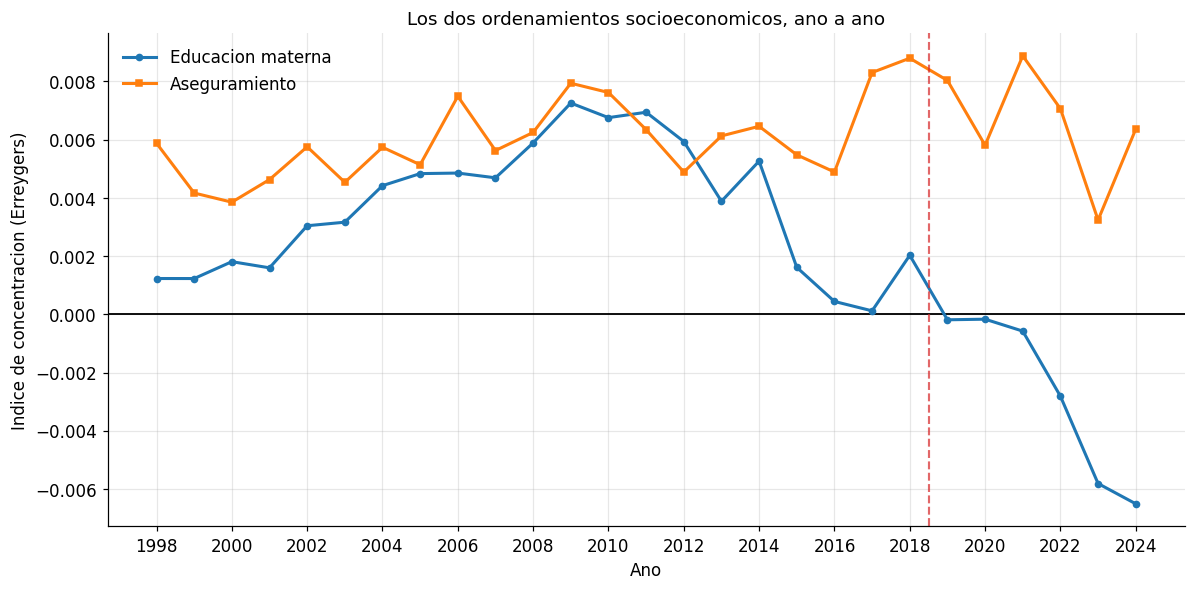


cambios de signo con educacion    : [(2018, 2019)]
cambios de signo con aseguramiento: ninguno
  educacion      tendencia con el ano: r = -0.547   +0.00123 -> -0.00651
  aseguramiento  tendencia con el ano: r = +0.395   +0.00588 -> +0.00636
  correlacion entre las dos series: 0.125


COMO CAMBIO LA COMPOSICION DE CADA ORDENAMIENTO

EDUC4_MADRE
   Ninguno o preescolar                       2.57 % ->   0.98 %  ( -1.59 pp)
   Primaria                                  34.70 % ->   9.12 %  (-25.57 pp)
   Secundaria                                51.95 % ->  57.38 %  ( +5.44 pp)
   Superior                                  10.79 % ->  32.51 %  (+21.72 pp)
   --> la categoria superior cambia +21.7 pp de tamano

SEGORD3
   No asegurado                              32.20 % ->   3.23 %  (-28.97 pp)
   Subsidiado                                26.92 % ->  55.99 %  (+29.07 pp)
   Contributivo, especial o de excepcion     40.88 % ->  40.78 %  ( -0.10 pp)
   --> la categoria superior cambia -0.1 pp

In [10]:
# ---------------------------------------------------------------------------
# Ordenamiento alternativo: aseguramiento
# ---------------------------------------------------------------------------

ORDEN_ALT = "SEGORD3"
ETIQUETAS_SEG = armonizar.etiquetas_de("SEGORD3")

tabla_alt = desigualdad.agrupar(muestra, ORDEN_ALT, "BPN")
tabla_alt["nivel"] = [ETIQUETAS_SEG[i] for i in tabla_alt[ORDEN_ALT]]
tabla_alt["rango_fraccional"] = desigualdad.rango_fraccional(
    tabla_alt["n"].to_numpy(dtype=float))
tabla_alt["prevalencia_pct"] = tabla_alt["prevalencia"] * 100

print("TABLA BASE — aseguramiento\n")
print(tabla_alt[[ORDEN_ALT, "nivel", "n", "casos", "prevalencia_pct",
                 "rango_fraccional"]]
      .to_string(index=False, float_format=lambda x: f"{x:9.4f}"))

ci_alt = desigualdad.indice_concentracion(tabla_alt)
ip_alt = desigualdad.indices_de_pendiente(tabla_alt)
bs_alt = desigualdad.bootstrap(tabla_alt, n_replicas=1000, semilla=SEMILLA)

# --- Comparacion lado a lado -----------------------------------------------
comparacion = pd.DataFrame([
    {"ordenamiento": "Educacion materna (4 niveles)",
     "niveles": ci["niveles"], "prevalencia_pct": ci["prevalencia_global"] * 100,
     "ci": ci["ci"], "erreygers": ci["erreygers"], "wagstaff": ci["wagstaff"],
     "sii_pp": ip["sii_pp"], "rii": ip["rii"], "r2": ip["r2"]},
    {"ordenamiento": "Aseguramiento (3 niveles)",
     "niveles": ci_alt["niveles"],
     "prevalencia_pct": ci_alt["prevalencia_global"] * 100,
     "ci": ci_alt["ci"], "erreygers": ci_alt["erreygers"],
     "wagstaff": ci_alt["wagstaff"], "sii_pp": ip_alt["sii_pp"],
     "rii": ip_alt["rii"], "r2": ip_alt["r2"]},
])
guardar_tabla(comparacion, "comparacion_ordenamientos", decimales=5)

print("\n\nCOMPARACION DE LOS DOS ORDENAMIENTOS\n")
print(comparacion.to_string(index=False, float_format=lambda x: f"{x:10.5f}"))

# --- El veredicto ----------------------------------------------------------
mismo_signo = np.sign(ci["erreygers"]) == np.sign(ci_alt["erreygers"])
print("\n" + "=" * 70)
if mismo_signo:
    print("LOS DOS ORDENAMIENTOS COINCIDEN EN SIGNO.")
    print("El resultado no depende de como se construyo la escala educativa:")
    print("un ordenamiento con otra variable, otro numero de niveles y otra")
    print("distribucion lleva a la misma direccion.")
else:
    print("LOS DOS ORDENAMIENTOS DISCREPAN EN SIGNO.")
    print("El resultado NO es robusto al ordenamiento elegido, y hay que")
    print("entender por que antes de interpretar ninguno de los dos.")
print("=" * 70)

print("\nIC 95 % con el ordenamiento por aseguramiento:")
print(bs_alt.to_string(index=False, float_format=lambda x: f"{x:12.6f}"))

# --- Serie anual del ordenamiento alternativo ------------------------------
# Si el cruce de signo de 2019 tambien aparece aqui, no es un efecto de la
# escala educativa: es un cambio en como se registra el bajo peso al nacer.
with cronometro("serie anual del ordenamiento alternativo"):
    serie_alt = desigualdad.serie_anual(muestra, ORDEN_ALT, "BPN")

guardar_tabla(serie_alt[["ANIO", "n", "prevalencia_global", "ci", "erreygers",
                         "sii_pp", "rii"]],
              "serie_anual_aseguramiento", decimales=5)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.axhline(0, color="black", linewidth=1.2)
ax.plot(serie["ANIO"], serie["erreygers"], marker="o", markersize=4,
        linewidth=2, label="Educacion materna")
ax.plot(serie_alt["ANIO"], serie_alt["erreygers"], marker="s", markersize=4,
        linewidth=2, label="Aseguramiento")
for _, valor in cruces:
    ax.axvline(valor - 0.5, color="tab:red", linestyle="--", linewidth=1.4,
               alpha=0.7)
ax.set_xlabel("Año de ocurrencia")
ax.set_ylabel("Indice de concentracion (Erreygers)")
ax.set_title("Los dos ordenamientos socioeconomicos, ano a ano")
ax.set_xticks(range(1998, 2025, 2))
ax.legend()

guardar_figura(fig, "fig_comparacion_ordenamientos")
plt.show()

signos_alt = np.sign(serie_alt["ci"].to_numpy())
cruces_alt = [(int(serie_alt["ANIO"].iloc[i]), int(serie_alt["ANIO"].iloc[i + 1]))
              for i in range(len(signos_alt) - 1)
              if signos_alt[i] * signos_alt[i + 1] < 0]
print(f"\ncambios de signo con educacion    : {cruces if cruces else 'ninguno'}")
print(f"cambios de signo con aseguramiento: {cruces_alt if cruces_alt else 'ninguno'}")

# --- Tendencia y parecido de las dos series --------------------------------
from scipy import stats
for nombre, s in [("educacion", serie), ("aseguramiento", serie_alt)]:
    r, _ = stats.pearsonr(s["ANIO"], s["erreygers"])
    print(f"  {nombre:<14} tendencia con el ano: r = {r:+.3f}   "
          f"{s['erreygers'].iloc[0]:+.5f} -> {s['erreygers'].iloc[-1]:+.5f}")
comun = serie[["ANIO", "erreygers"]].merge(serie_alt[["ANIO", "erreygers"]],
                                           on="ANIO", suffixes=("_edu", "_seg"))
print(f"  correlacion entre las dos series: "
      f"{stats.pearsonr(comun['erreygers_edu'], comun['erreygers_seg'])[0]:.3f}")

# --- Por que divergen: como cambio cada ordenamiento ------------------------
#
# SI LAS DOS SERIES DISCREPAN, LA CAUSA ESTA AQUI. El rango fraccional se
# recalcula cada anio, de modo que la POSICION relativa es comparable; pero si
# una categoria pasa de reunir al 11 % de la poblacion a reunir al 33 %, lo que
# significa pertenecer a ella no es lo mismo al principio que al final, y el
# indice de los dos extremos de la serie no mide exactamente la misma cosa.
#
# Esta tabla es la que permite decidir si un cambio temporal del indice refleja
# un cambio del fenomeno o un cambio del instrumento de medida.
print("\n\nCOMO CAMBIO LA COMPOSICION DE CADA ORDENAMIENTO\n")
for nombre, escala in [(ORDEN, "EDUC4"), (ORDEN_ALT, "SEGORD3")]:
    etqs = armonizar.etiquetas_de(escala)
    comp = pd.crosstab(muestra["ANIO"], muestra[nombre],
                       normalize="index").mul(100)
    cambio = comp.iloc[-1] - comp.iloc[0]
    print(f"{nombre}")
    for nivel in comp.columns:
        print(f"   {etqs.get(nivel, nivel):<40} "
              f"{comp[nivel].iloc[0]:6.2f} % -> {comp[nivel].iloc[-1]:6.2f} %  "
              f"({cambio[nivel]:+6.2f} pp)")
    # La categoria SUPERIOR es la que decide: si se diluye, la ventaja
    # asociada a ocuparla se diluye con ella.
    superior = comp.columns[-1]
    print(f"   --> la categoria superior cambia "
          f"{cambio[superior]:+.1f} pp de tamano\n")

**Cómo se lee esta salida.**

La tabla base del aseguramiento:

| Nivel | n | Prevalencia | Rango fraccional |
|---|---:|---:|---:|
| No asegurado | 2.525.812 | 8,36 % | 0,0746 |
| Subsidiado | 7.637.958 | 8,52 % | 0,3749 |
| Contributivo, especial o de excepción | 6.758.590 | 9,27 % | 0,8003 |

Y la comparación de los dos ordenamientos:

| | Educación (4 niveles) | Aseguramiento (3 niveles) |
|---|---:|---:|
| Prevalencia | 8,752 % | 8,795 % |
| CI | +0,01740 | **+0,02263** |
| **Erreygers** | **+0,00609** | **+0,00796** |
| Wagstaff | +0,01907 | +0,02481 |
| SII | +1,166 pp | **+1,420 pp** |
| RII | 1,1427 | 1,1756 |
| R² | 0,7449 | **0,9360** |

**Los dos ordenamientos coinciden en signo, y el alternativo da un gradiente algo más
marcado.** El resultado no es un artefacto de cómo se agregaron las categorías educativas:
una variable distinta, con tres niveles en vez de cuatro y una distribución distinta, lleva a
la misma dirección y a una magnitud del mismo orden.

**El R² de 0,94 en aseguramiento, frente a 0,74 en educación**, dice algo útil: el gradiente
por aseguramiento **sí es prácticamente monótono**, mientras que el educativo tiene la forma
en U. En aseguramiento, el SII es un buen resumen; en educación, hay que acompañarlo de la
advertencia.

**Y ahora lo que de verdad importa de este bloque: las dos series anuales divergen.**

| | Educación materna | Aseguramiento |
|---|---|---|
| 1998 | +0,00123 | +0,00588 |
| 2009 | +0,00726 (máximo) | +0,00794 |
| 2024 | **−0,00651** | **+0,00636** |
| Cambio de signo | **entre 2018 y 2019** | **ninguno** |
| Tendencia con el año | r = **−0,547** | r = +0,395 |

Correlación entre las dos series: **0,125**. Prácticamente no se parecen.

**El cruce de 2019 es específico del ordenamiento educativo.** El gradiente por aseguramiento
se mantiene positivo y sin tendencia clara los 27 años, oscilando alrededor de +0,006. Eso
**descarta** la lectura fácil del bloque anterior: si la inversión fuera un desvanecimiento
general del sesgo de detección, tendría que verse igual con los dos ordenamientos, y no se ve.

**La explicación está en cómo cambió cada ordenamiento, y es verificable:**

| Categoría superior | 1998 | 2024 | Cambio |
|---|---:|---:|---:|
| Educación «Superior» | 10,79 % | 32,51 % | **+21,7 pp** |
| Aseguramiento «Contributivo, especial o de excepción» | 40,88 % | 40,78 % | **−0,1 pp** |

**La categoría educativa alta se diluyó; la de aseguramiento no.** En 1998, «superior»
identificaba al 11 % más educado de las madres colombianas: una élite. En 2024 identifica a
un tercio de todas ellas. La etiqueta es la misma y el rango fraccional se recalcula cada
año, pero **lo que significa pertenecer a ese grupo cambió por completo**. La ventaja de
acceso y detección que iba asociada al privilegio educativo se diluyó al diluirse el grupo.

El régimen contributivo, en cambio, reúne hoy casi exactamente la misma fracción de madres
que en 1998 —el 41 %—; lo que se movió fue el reparto entre no asegurado y subsidiado, es
decir la parte baja del ordenamiento. Con la categoría superior estable, el gradiente es
estable.

**Qué se puede afirmar y qué no.**

Se puede afirmar que **la desigualdad medida por aseguramiento es estable y positiva** a lo
largo de todo el período, y que ese es el resultado robusto de la fase.

**No** se puede afirmar que la desigualdad educativa «se invirtió» en 2019 sin declarar de
inmediato que el ordenamiento educativo no es comparable entre los extremos de la serie. Las
dos lecturas posibles del cruce —que el gradiente social real emergió, o que la expansión
educativa vació de contenido la categoría superior— **no se pueden separar con estos datos**,
y presentar solo la primera sería sobreinterpretar.

**Lo que esto manda a la Fase 6.** La comprobación que sí puede distinguirlas: repetir el
índice educativo sobre grupos de tamaño comparable en cada año —por ejemplo el quintil
superior de la distribución educativa de cada año, en vez de la categoría nominal—. Si el
gradiente sigue invirtiéndose con grupos de tamaño fijo, la dilución no lo explica.

**Correspondencia con el manuscrito.** La tabla comparativa al Cuadro 5.3, como análisis de
robustez; la figura de las dos series a la Sección 5.2.4; la discusión de la no
comparabilidad del ordenamiento educativo entre años, a las limitaciones del Capítulo 6.

## 8. Cierre

**Qué hacemos.** Listamos lo producido e imprimimos las versiones de las bibliotecas.

In [11]:
# ---------------------------------------------------------------------------
# Cierre
# ---------------------------------------------------------------------------

from config import DIR_TABLAS, DIR_FIGURAS

print("RESUMEN DE LA FASE 3\n")
print(f"  ordenamiento principal   {ORDEN}")
print(f"  poblacion ordenable      {ci['n']:,}")
print(f"  indice de Erreygers      {ci['erreygers']:+.5f}")
print(f"  SII                      {ip['sii_pp']:+.3f} pp")
print(f"  RII                      {ip['rii']:.4f}")
print(f"  cambios de signo         {cruces if cruces else 'ninguno'}")

print("\nTABLAS")
for nombre in ["tabla_base_desigualdad", "curva_concentracion_educacion",
               "bootstrap_desigualdad_educacion", "serie_anual_desigualdad",
               "comparacion_ordenamientos", "serie_anual_aseguramiento"]:
    marca = "OK   " if (DIR_TABLAS / f"{nombre}.csv").exists() else "FALTA"
    print(f"  {marca}  {nombre}")

print("\nFIGURAS")
for nombre in ["fig_curva_concentracion_educacion", "fig_sii_educacion",
               "fig_serie_anual_desigualdad", "fig_comparacion_ordenamientos"]:
    marca = "OK   " if (DIR_FIGURAS / f"{nombre}.pdf").exists() else "FALTA"
    print(f"  {marca}  {nombre}")

print("\nINTERMEDIOS")
for f in sorted(DIR_INTERMEDIOS.glob("*.parquet")):
    print(f"  {f.name:<35} {f.stat().st_size / 1024**2:8.1f} MB")

print("\n" + "=" * 60)
versiones()

RESUMEN DE LA FASE 3

  ordenamiento principal   EDUC4_MADRE
  poblacion ordenable      16,820,098
  indice de Erreygers      +0.00609
  SII                      +1.166 pp
  RII                      1.1427
  cambios de signo         [(2018, 2019)]

TABLAS
  OK     tabla_base_desigualdad
  OK     curva_concentracion_educacion
  OK     bootstrap_desigualdad_educacion
  OK     serie_anual_desigualdad
  OK     comparacion_ordenamientos
  OK     serie_anual_aseguramiento

FIGURAS
  OK     fig_curva_concentracion_educacion
  OK     fig_sii_educacion
  OK     fig_serie_anual_desigualdad
  OK     fig_comparacion_ordenamientos

INTERMEDIOS
  indices_desigualdad.parquet              0.0 MB
  muestra_analitica.parquet              232.5 MB
  muestra_armonizada.parquet             109.0 MB
  particion.parquet                        2.1 MB
  prevalencia_anual.parquet                0.0 MB
  prevalencia_departamento.parquet         0.0 MB
  prevalencia_municipal_anual.parquet      0.2 MB
  prevalenc

## Qué sigue

**`04_multinivel.ipynb`, Fase 4.** Modelos logísticos multinivel. Lee
`intermedios/muestra_armonizada.parquet` y `intermedios/indices_desigualdad.parquet`.

Quien reproduzca este análisis debe comprobar antes estos cinco puntos:

- [ ] El índice de Erreygers global da **+0,00609** con educación y **+0,00796** con
      aseguramiento
- [ ] Los dos ordenamientos coinciden en signo **en el índice global**
- [ ] La curva de concentración **cruza** la diagonal: el gradiente educativo no es monótono
- [ ] El R² del ajuste lineal es **0,74** en educación y **0,94** en aseguramiento
- [ ] La serie educativa cambia de signo entre **2018 y 2019**; la de aseguramiento **no
      cambia de signo en ningún momento**

**Los tres resultados de esta fase, en orden de solidez.**

**Primero, y es el robusto.** El bajo peso al nacer registrado está levemente concentrado
entre las madres de **mayor** posición socioeconómica, y eso vale con los dos ordenamientos,
con las dos correcciones del índice y con los índices de pendiente. Es contrario a la
hipótesis del trabajo y a la literatura internacional, y la explicación que lo sostiene es el
sesgo de detección y registro: un recién nacido de bajo peso tiene que ser pesado, registrado
y sobrevivir para aparecer en las estadísticas vitales, y las tres cosas dependen del acceso
a atención médica.

**Segundo, y es el que hay que declarar con cuidado.** La serie educativa se invierte a lo
largo del período y la de aseguramiento no. La causa más probable no es que el sesgo se haya
desvanecido, sino que la categoría educativa superior pasó del 11 % al 33 % de las madres
mientras la de aseguramiento se mantuvo en el 41 %. **Un ordenamiento cuya categoría
superior se diluye deja de medir lo mismo al principio y al final de la serie.**

**Tercero, lo que queda abierto.** Con estos datos no se puede separar «emergió el gradiente
social real» de «se vació de contenido la categoría educativa alta». Requiere una
comprobación específica y es trabajo de la Fase 6.

**Lo que esta fase manda a la Fase 6**, ahora concreto:

1. **Grupos de tamaño fijo.** Repetir el índice educativo usando el quintil superior de la
   distribución de cada año en vez de la categoría nominal. Si el gradiente sigue
   invirtiéndose, la dilución no lo explica y el hallazgo es del fenómeno.
2. **Partos institucionales.** Restringir a los nacimientos ocurridos en institución de
   salud, donde el pesaje es sistemático. Si el gradiente se atenúa, el sesgo de detección
   queda documentado con evidencia propia.
3. **Escala educativa detallada.** Repetir el índice con los 13 niveles sobre 2008-2024, para
   comprobar que la agregación a cuatro niveles no produjo el signo.

**Y una decisión que corresponde al director**, no al código: si el análisis principal debe
cubrir los 27 años o restringirse a los de cobertura estable. Afecta a las Fases 4 a 7 y
conviene resolverla antes de ajustar los modelos multinivel.